- [1단계: 실시간 데이터 로더 (PyTorch3D)]
<br> - 무작위 도형 조합 생성 
<br> - 가상 카메라 2~3대 배치 후 이미지 렌더링 -> 입력 데이터 (Image 2~3)
<br> - 해당 도형의 실제 3D 좌표 추출 -> 정답 데이터 (GT Point Cloud)
- [2단계: 경량 3D 재구성 모델 (우리 모델)]
<br> - 입력(Image 2~3) → 경량 2D 인코더 → 가벼운 3D 디코더
<br> - 출력: 예측된 3D 포인트 클라우드 (Pred Point Cloud)
- [3단계: SimpleNet 방식의 이상 탐지 학습]
<br> - 진짜 정답(GT Point Cloud) 추출
<br> - [정상 데이터]로 취급하여 학습
<br> - 여기에 가우시안 노이즈를 섞어 분포를 비튼 [가짜 불량 데이터] 생성
<br> - 판별기(Discriminator)가 진짜 정답과 가짜 노이즈 데이터를 구분하도록 학습

##### [1단계: 실시간 데이터 로더 (PyTorch3D)]

추출된 3D 좌표 형상 (Shape): (2048, 3)


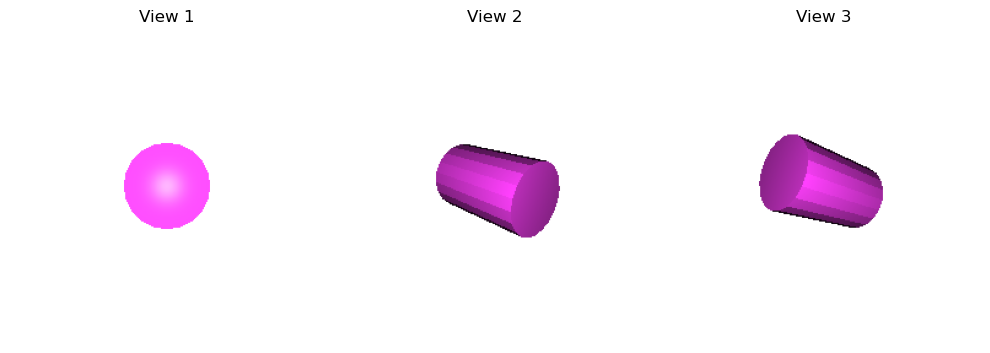

3D 시각화 창을 띄웁니다. (창을 닫으면 프로세스가 계속됩니다.)


In [1]:
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
import trimesh

# 1개의 랜덤한 도형
def generate_random_geometry():
    """1.
       무작위 도형(구, 상자, 실린더 중 하나)을 생성하고, 다각도 이미지 3장을 렌더링합니다.
    """
    # 무작위 도형 선택
    geom_type = np.random.choice(["cube", "sphere", "cylinder"])
    if geom_type == "cube":
        mesh = o3d.geometry.TriangleMesh.create_box(
            width=1.0, height=1.0, depth=1.0
        )
    elif geom_type == "sphere":
        mesh = o3d.geometry.TriangleMesh.create_sphere(radius=0.6)
    else:
        mesh = o3d.geometry.TriangleMesh.create_cylinder(
            radius=0.4, height=1.2
        )

    mesh.compute_vertex_normals()
    mesh.paint_uniform_color(np.random.rand(3))  # 무작위 색상

    # 가상 카메라 각도 설정 (정면, 측면, 반대측면)
    view_angles = [
        {"zoom": 1.5, "front": [0, 0, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [1, 0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [-1, -0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0],},
        ]

    images = []
    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=256, height=256)
    vis.add_geometry(mesh)
    vis.get_render_option().point_size = 3.0

    # 각 각도에서 이미지 렌더링
    ctr = vis.get_view_control()
    for angle in view_angles:
        ctr.set_zoom(angle["zoom"])
        ctr.set_front(angle["front"])
        ctr.set_lookat(angle["lookat"])
        ctr.set_up(angle["up"])
        vis.poll_events()
        vis.update_renderer()
        img = vis.capture_screen_float_buffer(do_render=True)
        images.append(np.asarray(img))

    vis.destroy_window()
    return mesh, images

# 1~5개의 랜덤한 도형 조합
def generate_random_geometry2():
    """1.
    기본 도형들을 무작위 위치와 크기로 3~5개 결합하여 복잡한 블록 조합을 생성하고, 다각도 이미지 3장을 렌더링합니다.
    """
    # 결합할 빈 메쉬 생성
    combined_mesh = o3d.geometry.TriangleMesh()

    # 3개에서 5개 사이의 무작위 블록을 쌓음
    num_blocks = np.random.randint(1, 3)

    for _ in range(num_blocks):
        # 무작위 도형 타입 선택
        geom_type = np.random.choice(["cube", "sphere", "cylinder"])

        if geom_type == "cube":
            # 무작위 가로, 세로, 높이 (0.3 ~ 0.7 사이)
            w, h, d = np.random.uniform(0.3, 1.0, 3)
            mesh = o3d.geometry.TriangleMesh.create_box(
                width=w, height=h, depth=d
            )
            # Box는 좌하단 기준 생성이므로 중심을 원점으로 맞추기 위한 이동
            mesh.translate([-w / 2, -h / 2, -d / 2])
        elif geom_type == "sphere":
            r = np.random.uniform(0.2, 0.8)
            mesh = o3d.geometry.TriangleMesh.create_sphere(radius=r)
        else:
            r = np.random.uniform(0.15, 0.3)
            h = np.random.uniform(0.4, 0.8)
            mesh = o3d.geometry.TriangleMesh.create_cylinder(
                radius=r, height=h
            )
            mesh.translate([0, 0, -h / 2])  # 중심 맞추기

        # 블록을 무작위 위치로 이동 (X, Y, Z 각각 -0.4 ~ 0.4 범위)
        random_translation = np.random.uniform(-0.4, 0.4, 3)
        mesh.translate(random_translation)

        # 블록에 무작위 회전 적용
        R = mesh.get_rotation_matrix_from_xyz(np.random.uniform(0, np.pi, 3))
        mesh.rotate(R, center=(0, 0, 0))

        # 메쉬 합치기
        combined_mesh += mesh
    
    vertices = np.asarray(combined_mesh.vertices)
    triangles = np.asarray(combined_mesh.triangles)
    tm_mesh = trimesh.Trimesh(vertices=vertices, faces=triangles)

    # [선택 A] 복합 고형 연산 (Boolean Union)
    # 얽힌 메쉬들의 내부 경계면을 완전히 녹여서 하나의 원자적 껍데기로 만듭니다.
    # 만약 에러가 발생하거나 속도가 느리다면 아래 [선택 B]로 대체하세요.
    try:
        cleaned_tm_mesh = tm_mesh.process(validate=True)
        # 겉 표면(외곽선)만 남기고 내부 분할면을 지우는 연산
        cleaned_tm_mesh = cleaned_tm_mesh.convex_hull
    except:
        # [선택 B] 체적 기반으로 외부 표면(만질 수 있는 면)만 추출
        # 완전히 밀폐된(Watertight) 외부 쉘만 남기고 내부 인프라를 통째로 날립니다.
        cleaned_tm_mesh = trimesh.repair.broken_faces(tm_mesh)
        cleaned_tm_mesh = tm_mesh.split()[
            0
        ]  # 가장 부피가 큰 외곽 덩어리만 선택

    # 3. 깨끗해진 trimesh를 다시 Open3D 메쉬 타입으로 완벽히 복원합니다.
    # 이 과정 덕분에 뒤이은 Open3D 기반 렌더링 코드가 깨지지 않습니다.
    surface_mesh = o3d.geometry.TriangleMesh()
    surface_mesh.vertices = o3d.utility.Vector3dVector(cleaned_tm_mesh.vertices)
    surface_mesh.triangles = o3d.utility.Vector3iVector(cleaned_tm_mesh.faces)

    # 원본 변수에 새 메쉬를 할당하여 기존 흐름을 유지합니다.
    combined_mesh = surface_mesh

    combined_mesh.compute_vertex_normals()
    combined_mesh.paint_uniform_color(np.random.rand(3))  # 무작위 색상

    # 가상 카메라 각도 설정 (정면, 측면, 반대측면)
    view_angles = [
        {"zoom": 1.5, "front": [0, 0, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [1, 0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0]},
        {"zoom": 1.5, "front": [-1, -0.5, -1], "lookat": [0, 0, 0], "up": [0, 1, 0],},
        ]

    images = []
    vis = o3d.visualization.Visualizer()
    vis.create_window(visible=False, width=256, height=256)
    vis.add_geometry(combined_mesh)

    # 각 각도에서 이미지 렌더링
    ctr = vis.get_view_control()
    for angle in view_angles:
        ctr.set_zoom(angle["zoom"])
        ctr.set_front(angle["front"])
        ctr.set_lookat(angle["lookat"])
        ctr.set_up(angle["up"])
        vis.poll_events()
        vis.update_renderer()
        img = vis.capture_screen_float_buffer(do_render=True)
        images.append(np.asarray(img))

    vis.destroy_window()
    
    
    return combined_mesh, images


def extract_3d_coordinates(mesh, num_points=1024):
    """2.
    생성된 3D 메쉬 표면에서 고정된 개수의 3D 좌표(Point Cloud)를 추출합니다 (Ground Truth).
    """
    pcd = mesh.sample_points_uniformly(number_of_points=num_points)
    points = np.asarray(pcd.points)
    return points


def visualize_results(images, points):
    """3.
    생성된 2D 이미지들과 추출된 3D 포인트 클라우드를 각각 시각화합니다.
    """
    
    fig, axes = plt.subplots(1, len(images), figsize=(10, 4))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].set_title(f"View {i+1}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    # 3D 포인트 클라우드 시각화 (Open3D 창 팝업)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd.paint_uniform_color([0, 0, 1])  # 파란색으로 표현
    print("3D 시각화 창을 띄웁니다. (창을 닫으면 프로세스가 계속됩니다.)")
    o3d.visualization.draw_geometries([pcd], width=250, height=250)


# - [1단계: 실시간 데이터 로더 (PyTorch3D)]
def create_data(data_num=1, draw_plots=False, num_points=1024):
    image_datas = []
    gt_datas = []
    for _ in range(data_num):
        # 1. 도형 및 이미지 생성
        mesh, generated_images = generate_random_geometry()
        # 2. 3D 좌표(GT) 추출
        gt_points = extract_3d_coordinates(mesh, num_points)
        # 3. 시각화 확인
        if draw_plots:
            print(f"추출된 3D 좌표 형상 (Shape): {gt_points.shape}")
            visualize_results(generated_images, gt_points)

        image_datas.append(generated_images)
        gt_datas.append(gt_points)
    return image_datas, gt_datas



image_datas, gt_datas = create_data(data_num=1, draw_plots=True, num_points=1024*2)

In [2]:
# - [2단계: 경량 3D 재구성 모델] 
import torch
import torch.nn as nn
import copy
import torch.nn.functional as F

class Light3DReconstructModel(nn.Module):

    def __init__(self, num_output_points=1024):
        super().__init__()
        self.num_output_points = num_output_points

        def feature_extractor():
            extractor = nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),  # 128x128
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 64x64
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 32x32
                nn.BatchNorm2d(128),
                nn.ReLU(),
            )
            return extractor
        
        def feature_aggregator(feat_dim, geom_dim):
            aggregator = nn.Sequential(
                nn.Conv2d(feat_dim + geom_dim, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),

                nn.Conv2d(32, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(),
                
                # 각 뷰의 독립적인 로컬 입체감을 한 번 더 정제
                nn.Conv2d(16, 8, kernel_size=3, padding=1),
                nn.BatchNorm2d(8),
                nn.ReLU()
            )
            return aggregator
        
        # 1. 초경량 커스텀 2D CNN 백본
        # 입력: (Batch, 3, 256, 256) -> 출력: (Batch, 128, 16, 16)
        self.feature_extractor1 = feature_extractor()
        self.feature_extractor2 = feature_extractor()
        
        sobel_x = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        sobel_y = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=torch.float32).view(1, 1, 3, 3)
        # 미세한 요철과 텍스처 깊이감을 돋보이게 하는 Laplacian 커널
        laplacian = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=torch.float32).view(1, 1, 3, 3)
        
        # 가중치가 학습되지 않도록 고정 (Parameter 0개 효과)
        self.register_buffer('kernel_x', sobel_x)
        self.register_buffer('kernel_y', sobel_y)
        self.register_buffer('kernel_lap', laplacian)
        
        feat_dim=128
        geom_dim=3
        self.agg1 = feature_aggregator(feat_dim, geom_dim)
        self.agg2 = feature_aggregator(feat_dim, geom_dim)
        
        def feature_adaptor():
            extractor = nn.Sequential(
                nn.Conv2d(24, 16, kernel_size=3, stride=2, padding=1), # (Batch, 16, 16, 16)
                nn.BatchNorm2d(16),
                nn.ReLU(),

                nn.Conv2d(16, 8, kernel_size=3, stride=2, padding=1), # (Batch, 8, 8, 8)
                nn.BatchNorm2d(8),
                nn.ReLU(),

                nn.Flatten(),
                nn.Linear(8 * 8 * 8, num_output_points * 2),
                nn.ReLU(),
            )
            return extractor

        def decoder_layer():
            decoder = nn.Sequential(
                nn.Flatten(),
                nn.Linear(num_output_points * 2, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return decoder
        
        def spread_layer():
            decoder = nn.Sequential(
                nn.Linear(num_output_points * 3, num_output_points),
                nn.ReLU(),
                nn.Linear(num_output_points, num_output_points * 3),  # (1024 * 3)
            )
            return decoder
        
        self.adaptor_lyr1 = feature_adaptor()
        self.adaptor_lyr2 = feature_adaptor()
        self.deform_lyr1 = decoder_layer()
        self.deform_lyr2 = decoder_layer()
        self.spread_lyr1 = spread_layer()
        self.spread_lyr2 = spread_layer()

        self.num_output_points = num_output_points

    def forward(self, img1, img2, img3):
        batch_size = img1.size(0)

        # 트랙 1: 정방향 순서로 1번 추출기 통과
        f1_1 = self.feature_extractor1(img1)
        f1_2 = self.feature_extractor1(img2)
        f1_3 = self.feature_extractor1(img3)
        # 3개 뷰 결합 -> (Batch, 128*3, 32, 32)

        # 트랙 2: 역방향 순서로 2번 추출기 통과
        f2_3 = self.feature_extractor2(img3)
        f2_2 = self.feature_extractor2(img2)
        f2_1 = self.feature_extractor2(img1)
        # 3개 뷰 결합 -> (Batch, 128*3, 32, 32)

        # 트랙 3: [명암 디테일 융합] 이미지 3장의 색상/밝기 픽셀 분포 추출 ([8, 128])
        def geom_feat(img, target_size):
            # img: [Batch, 3, H, W] -> 흑백(Luminance)에 가까운 채널별 평균 맵으로 변환
            gray = img.mean(dim=1, keepdim=True) # [Batch, 1, H, W]
            
            # 각각의 필터 적용 (경계면 패딩 유지)
            grad_x = F.conv2d(gray, self.kernel_x, padding=1)
            grad_y = F.conv2d(gray, self.kernel_y, padding=1)
            lap = F.conv2d(gray, self.kernel_lap, padding=1)
            # 1) 전체 기울기 강도 (음영의 급격한 변화 = 깊이 단차)
            grad_magnitude = torch.sqrt(grad_x ** 2 + grad_y ** 2 + 1e-6)
            # 2) 원본 그레이스케일 + 기울기 + 요철 피처를 한데 묶음
            # 입체적 정보가 가득 담긴 3채널의 'Geom-Map'이 완성됩니다.
            geom_features = torch.cat([gray, grad_magnitude, lap], dim=1) # [Batch, 3, H, W]
            return F.interpolate(geom_features, size=target_size, mode='bilinear', align_corners=False)
        
        geo_feat1 = geom_feat(img1, (f1_1.shape[2], f1_1.shape[3]))
        geo_feat2 = geom_feat(img2, (f1_2.shape[2], f1_2.shape[3]))
        geo_feat3 = geom_feat(img3, (f1_3.shape[2], f1_3.shape[3]))
      
        input1_agg1 = self.agg1(torch.cat([f1_1, geo_feat1], dim=1)) # (8, 8, 32, 32)
        input1_agg2 = self.agg1(torch.cat([f1_2, geo_feat2], dim=1))
        input1_agg3 = self.agg1(torch.cat([f1_3, geo_feat3], dim=1))
        input_ext1 = torch.cat([input1_agg1, input1_agg2, input1_agg3], dim=1) # (8, 8*3, 32, 32)

        input2_agg1 = self.agg2(torch.cat([f2_1, geo_feat1], dim=1))
        input2_agg2 = self.agg2(torch.cat([f2_2, geo_feat2], dim=1))
        input2_agg3 = self.agg2(torch.cat([f2_3, geo_feat3], dim=1))
        input_ext2 = torch.cat([input2_agg1, input2_agg2, input2_agg3], dim=1)

        # torch.Size([8, 16, 16, 16])
        first_points1 = self.deform_lyr1(self.adaptor_lyr1(input_ext1))
        # second_points1 = self.spread_lyr1(first_points1)
        # pred_points1 = self.spread_lyr1(second_points1)
        # 기존의 쌩뚱맞은 출력이 아니라, "초안 점군에서 얼마큼 이동(Residual)해야 하는지"를 학습시킵니다.
        second_points1_offset = self.spread_lyr1(first_points1) 
        second_points1 = first_points1 + second_points1_offset  # 잔차(Residual) 커넥션 형성

        pred_points1_offset = self.spread_lyr1(second_points1)
        pred_points1 = second_points1 + pred_points1_offset


        first_points2 = self.deform_lyr2(self.adaptor_lyr2(input_ext2))
        # second_points2 = self.spread_lyr2(first_points2)
        # pred_points2 = self.spread_lyr2(second_points2)
        second_points2_offset = self.spread_lyr2(first_points2) 
        second_points2 = first_points2 + second_points2_offset  # 잔차(Residual) 커넥션 형성

        pred_points2_offset = self.spread_lyr2(second_points2)
        pred_points2 = second_points2 + pred_points2_offset
        
        return [first_points1.view(batch_size, self.num_output_points, 3), 
                first_points2.view(batch_size, self.num_output_points, 3), 
                second_points1.view(batch_size, self.num_output_points, 3), 
                second_points2.view(batch_size, self.num_output_points, 3), 
                pred_points1.view(batch_size, self.num_output_points, 3), 
                pred_points2.view(batch_size, self.num_output_points, 3)]

def point_density_loss(pred_points, gt_points, k=5, eps=1e-8):
    """pred_points: (Batch, N, 3)
    k: 체크할 가까운 이웃 점의 개수
    """
    B, N, C = pred_points.shape

    # 1. Pairwise Distance 계산 (수치 안정성을 위해 L1-norm 또는 안전한 L2 사용)
    # 메모리 절약 및 그라디언트 안정성을 위해 sqrt에 eps를 더해 거리를 구합니다.
    diff = pred_points.unsqueeze(2) - pred_points.unsqueeze(1)  # (B, N, N, 3)
    dist_matrix = torch.sqrt(torch.sum(diff**2, dim=-1) + eps)  # (B, N, N)

    # 2. 자기 자신과의 거리 제외 (큰 값 더하기)
    eye = (
        torch.eye(N, device=pred_points.device).unsqueeze(0).expand(B, -1, -1)
    )
    dist_matrix = dist_matrix + (eye * 1e6)

    # 3. 가장 가까운 k개의 이웃 점과의 실제 거리 추출
    topk_dists, _ = torch.topk(dist_matrix, k=k, dim=-1, largest=False)  # (B, N, k)

    # 각 점별로 k개 이웃과의 '평균 거리'를 계산 -> (B, N)
    mean_dists_per_point = torch.mean(topk_dists, dim=-1)

    # 4. [핵심 수정] 양방향 패널티 부여 (상대적 균일화)
    # 현재 배치/점군 내에서 모든 점들이 가져야 할 '가장 이상적인 평균 거리'의 기준점을 잡습니다.
    # 이 값은 점들이 전체적으로 퍼져있을 때의 평균 거리 역할을 합니다.
    ideal_global_dist = torch.mean(mean_dists_per_point, dim=-1, keepdim=True)

    # - 어떤 점의 이웃 거리가 ideal_global_dist보다 너무 작다 = 과밀집 (패널티)
    # - 어떤 점의 이웃 거리가 ideal_global_dist보다 너무 크다 = 과소밀집/고립 (패널티)
    # 두 차이를 제곱하여 분산(Variance) 형태로 패널티를 줍니다.
    density_penalty = torch.mean((mean_dists_per_point - ideal_global_dist) ** 2)

    return density_penalty

def chamfer_distance_loss(pred_points, gt_points):
    """점의 개수가 달라도 표면의 밀도와 덮임 정도를 비교하는 Chamfer Distance 손실 함수.
    pred_points: (Batch, N, 3) -> 모델이 예측한 점 (1024개) gt_points: (Batch, M, 3) -> 진짜 정답 점 (4096개)
    """
    # 서로 다른 크기의 점군 거리 계산을 위해 브로드캐스팅 활용
    # (B, N, 1, 3) - (B, 1, M, 3) -> (B, N, M, 3)
    diff = pred_points.unsqueeze(2) - gt_points.unsqueeze(1)
    dist_matrix = torch.sum(diff**2, dim=-1)  # 각 점 쌍 사이의 L2 거리 제곱: (B, N, M)

    # 1. 예측된 각 점마다 가장 가까운 GT 점까지의 최소 거리 (B, N)
    src_to_tgt_dist, _ = torch.min(dist_matrix, dim=2)

    # 2. GT의 각 점마다 가장 가까운 예측 점까지의 최소 거리 (B, M)
    tgt_to_src_dist, _ = torch.min(dist_matrix, dim=1)

    # 양방향 오차의 평균을 더함
    loss = torch.mean(src_to_tgt_dist) + torch.mean(tgt_to_src_dist)
    return loss

def normal_consistency_loss(pred_points, gt_points, k=8):
    """예측 점군(1024개)과 정답 점군(4096개)의 개수가 달라도 에러 없이 각 표면의 법선 벡터(Normal) 방향 일치도를 계산합니다.
    pred_points: (Batch, N_pred, 3)  -> 예: (8, 1024, 3)
    gt_points: (Batch, N_gt, 3)      -> 예: (8, 4096, 3)
    k: 국소 평면을 추정할 이웃 점의 개수
    """
    B, N_pred, _ = pred_points.shape
    _, N_gt, _ = gt_points.shape
    device = pred_points.device

    # =========================================================================
    # 1. 예측 점군(Pred)의 법선 벡터 계산 (N_pred = 1024 기준)
    # =========================================================================
    dist_matrix_pred = torch.cdist(pred_points, pred_points)  # (B, N_pred, N_pred)
    _, knn_idx_pred = torch.topk(
        dist_matrix_pred, k=k + 1, largest=False, dim=-1
    )
    knn_idx_pred = knn_idx_pred[:, :, 1:]  # 자기 자신 제외 -> (B, N_pred, k)

    flat_idx_pred = knn_idx_pred.reshape(B, -1).unsqueeze(-1).expand(-1, -1, 3)
    neighbors_pred = torch.gather(pred_points, 1, flat_idx_pred).view(
        B, N_pred, k, 3
    )

    # 국소 대표 축 2개의 외적(Cross Product)으로 평면의 법선 방향 계산
    v1_pred = neighbors_pred[:, :, 0, :] - pred_points
    v2_pred = neighbors_pred[:, :, 1, :] - pred_points
    pred_normals = torch.cross(v1_pred, v2_pred, dim=-1)
    pred_normals = torch.nn.functional.normalize(pred_normals, p=2, dim=-1)

    # =========================================================================
    # 2. 정답 점군(GT)의 법선 벡터 계산 (N_gt = 4096 기준) - [이 부분을 분리 수정]
    # =========================================================================
    dist_matrix_gt = torch.cdist(gt_points, gt_points)  # (B, N_gt, N_gt)
    _, knn_idx_gt = torch.topk(dist_matrix_gt, k=k + 1, largest=False, dim=-1)
    knn_idx_gt = knn_idx_gt[:, :, 1:]  # 자기 자신 제외 -> (B, N_gt, k)

    flat_idx_gt = knn_idx_gt.reshape(B, -1).unsqueeze(-1).expand(-1, -1, 3)
    # [교정]: N_pred 대신 N_gt(4096)를 명시하여 view 차원 불일치 에러를 완벽히 해결합니다.
    neighbors_gt = torch.gather(gt_points, 1, flat_idx_gt).view(B, N_gt, k, 3)

    v1_gt = neighbors_gt[:, :, 0, :] - gt_points
    v2_gt = neighbors_gt[:, :, 1, :] - gt_points
    gt_normals = torch.cross(v1_gt, v2_gt, dim=-1)
    gt_normals = torch.nn.functional.normalize(gt_normals, p=2, dim=-1)

    # =========================================================================
    # 3. 개수가 다른 두 점군의 법선 벡터 비교 ( Chamfer 매칭 연산과 융합 )
    # 예측 점(1024개) 각각에 대해 '가장 물리적으로 가까운 정답 점(4096개 중 하나)'을 찾아
    # 그 지점의 법선 벡터끼리 방향을 대조합니다.
    # =========================================================================
    # 두 점군 간의 상호 거리 매트릭스 계산 -> (B, N_pred, N_gt)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 예측 점 각각이 어떤 정답 점과 가장 가까운지 최단거리 인덱스 추출 -> (B, N_pred)
    _, closest_gt_idx = torch.min(cross_dist, dim=-1)

    # 가장 가까운 정답 지점의 법선 벡터들을 수집 -> (B, N_pred, 3)
    flat_gt_idx = closest_gt_idx.unsqueeze(-1).expand(-1, -1, 3)
    matched_gt_normals = torch.gather(gt_normals, 1, flat_gt_idx)

    # 매칭된 법선 벡터끼리의 코사인 유사도 계산 (방향 일치도)
    cos_sim = torch.abs(torch.sum(pred_normals * matched_gt_normals, dim=-1))

    # 최종 Loss 반환 (방향이 다를수록 커짐)
    return torch.mean(1.0 - cos_sim)

def uncovered_surface_penalty_loss(pred_points, gt_points, threshold=0.01):
    """정답(GT) 표면 중에서 주변에 예측된 점이 없어 텅 빈 구멍(Hole)이 생긴 영역에

    강력한 패널티를 부여합니다. (모델이 사방으로 펼쳐지도록 강제)
    threshold: 이 반경 내에 예측 점이 최소 하나는 있어야 '덮었다'고 인정하는 기준
    """
    # 1. 상호 거리 매트릭스 계산 (Batch, 1024, 4096)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 2. [핵심] 정답 점(4096개) 기준으로 가장 가까운 예측 점까지의 거리 추출
    # min_dist_per_gt 차원: (Batch, 4096)
    min_dist_per_gt, _ = torch.min(cross_dist, dim=1)

    # 3. 설정한 threshold 반경을 넘어서서 '방치된' 정답 표면의 오차 가로채기
    # 반경 내에 잘 들어온 곳은 0이 되고, 점이 없어 텅 빈 구멍 영역만 양수(+)가 남음
    coverage_violations = torch.clamp(min_dist_per_gt - threshold, min=0.0)

    # 4. 비선형 패널티 부과 (제곱하여 아예 방치된 구멍은 Loss가 무지막지하게 커지도록 설정)
    penalty = torch.pow(coverage_violations, 2)

    return torch.mean(penalty)

def surface_bound_penalty_loss(pred_points, gt_points, epsilon=0.005):
    """예측된 점이 정답 표면의 허용 반경(epsilon)을 벗어나
    외부 공중이나 내부 뱃속에 찍힐 경우 강력한 패널티를 부과합니다.
    epsilon: 표면이라고 인정해 줄 미세 두께 (이 범위를 벗어나면 아웃라이어로 판단)
    """
    # 1. 예측 점(1024개) 각각에서 정답 표면(4096개)까지의 최단 거리 계산
    # cross_dist 차원: (Batch, 1024, 4096)
    cross_dist = torch.cdist(pred_points, gt_points)

    # 각 예측 점마다 가장 가까운 표면 점까지의 오차 거리 추출 -> (Batch, 1024)
    min_distances, _ = torch.min(cross_dist, dim=-1)

    # 2. [핵심] 허용 반경 epsilon을 빼서, 표면을 벗어난 오차만 추출
    # 표면 근처(<= epsilon)에 잘 찍힌 점들은 0이 되고, 벗어난 점들만 양수(+)가 남음
    boundary_violations = torch.clamp(min_distances - epsilon, min=0.0)

    # 3. 비선형 패널티 부과 (제곱 연산을 통해 멀리 떨어질수록 Loss가 폭발적으로 증가)
    penalty = torch.pow(boundary_violations, 4)

    # 배치 및 점 전체 평균 반환
    return torch.mean(penalty)

def total_loss_fn1(pred_points, gt_points, train=False):
    def criterion(pred_points, gt_points):
        cd_loss = chamfer_distance_loss(pred_points, gt_points)
        pt_dense_loss = point_density_loss(pred_points, gt_points)
        normal_loss = normal_consistency_loss(pred_points, gt_points, k=8)
        outside_penalty = surface_bound_penalty_loss(pred_points, gt_points, epsilon=1e-7)
        uncovered_penalty = uncovered_surface_penalty_loss(pred_points, gt_points, threshold=1e-7)
        return 4.0 * cd_loss + 2.0 * pt_dense_loss + 2.0 * normal_loss + 5.0 * outside_penalty + 5.0 * uncovered_penalty

    pred_points1, pred_points2 = pred_points
    loss_indiv = (criterion(pred_points1, gt_points) + criterion(pred_points2, gt_points)) / 2.0
    loss_consistency = chamfer_distance_loss(pred_points1, pred_points2)
    
    # 3. 일관성 오차 (서로 헷갈리지 않게 묶어주는 끈) 
    # 한쪽 뷰에서 놓친 표면을 다른 뷰의 결과물이 채워주도록 상호 견제합니다.
    total_loss = 0.5 * loss_indiv + 0.5 * loss_consistency
    return total_loss

def total_loss_fn(pred_points, gt_points, train=False):
    first_points1, first_points2, second_points1, second_points2, pred_points1, pred_points2 = pred_points

    loss_coarse1 = chamfer_distance_loss(first_points1, gt_points) + uncovered_surface_penalty_loss(first_points1, gt_points, threshold=1e-7)
    loss_coarse2 = chamfer_distance_loss(first_points2, gt_points) + uncovered_surface_penalty_loss(first_points2, gt_points, threshold=1e-7)

    # 2차 Fine 단계: 실제 최종 성적이므로 메인 가중치(1.0)를 줍니다.
    loss_fine1 = chamfer_distance_loss(second_points1, gt_points) + surface_bound_penalty_loss(second_points1, gt_points, epsilon=1e-7)
    loss_fine2 = chamfer_distance_loss(second_points2, gt_points) + surface_bound_penalty_loss(second_points2, gt_points, epsilon=1e-7)

    loss_fine21 = chamfer_distance_loss(pred_points1, gt_points) + point_density_loss(pred_points1, gt_points)
    loss_fine22 = chamfer_distance_loss(pred_points2, gt_points) + point_density_loss(pred_points2, gt_points)

    total_chamfer_loss = (loss_coarse1 + loss_coarse2) + 1.0 * (loss_fine1 + loss_fine2) + 1.0 * (loss_fine21 + loss_fine22)

    loss_consistency = chamfer_distance_loss(pred_points1, pred_points2)

    total_loss = 0.5 * total_chamfer_loss + 0.5 * loss_consistency
    return total_loss
    
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0):
        """patience (int): Loss가 개선되지 않아도 참아줄 에폭 횟수 min_delta (float):
        개선되었다고 판단할 최소한의 변화량
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.early_stop = False
        self.best_model_wts = None

    def __call__(self, val_loss, model):
        # 만약 학습 Loss 기준으로 하신다면 훈련 루프의 Avg_Loss를 넣어주시면 됩니다.
        if val_loss < self.best_loss - self.min_delta:
            # 최저 Loss 갱신 성공
            self.best_loss = val_loss
            self.best_model_wts = copy.deepcopy(model.state_dict())
            self.counter = 0  # 카운터 리셋
            print(
                f" -> [Best Model Saved] Lowest Loss reached: {self.best_loss:.4f}"
            )
        else:
            # Loss가 줄어들지 않음
            self.counter += 1
            print(
                f" -> [EarlyStopping Counter] {self.counter} / {self.patience}"
            )

            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        """조기 종료 후 가장 성능이 좋았던 시점의 가중치로 복구"""
        if self.best_model_wts is not None:
            model.load_state_dict(self.best_model_wts)
            print(" -> [Restored] Loaded the best model weights.")

from torchinfo import summary
print(summary(Light3DReconstructModel(num_output_points=512)))


Layer (type:depth-idx)                   Param #
Light3DReconstructModel                  --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─BatchNorm2d: 2-2                  64
│    └─ReLU: 2-3                         --
│    └─Conv2d: 2-4                       18,496
│    └─BatchNorm2d: 2-5                  128
│    └─ReLU: 2-6                         --
│    └─Conv2d: 2-7                       73,856
│    └─BatchNorm2d: 2-8                  256
│    └─ReLU: 2-9                         --
├─Sequential: 1-2                        --
│    └─Conv2d: 2-10                      896
│    └─BatchNorm2d: 2-11                 64
│    └─ReLU: 2-12                        --
│    └─Conv2d: 2-13                      18,496
│    └─BatchNorm2d: 2-14                 128
│    └─ReLU: 2-15                        --
│    └─Conv2d: 2-16                      73,856
│    └─BatchNorm2d: 2-17                 256
│    └─ReLU: 2-18                        --
├─Seq

In [3]:
from matplotlib.pyplot import step
import torch.optim as optim
from tqdm import tqdm 

def create_batch(batch_size=4):
    """지정된 batch_size만큼 create_data를 호출하여 이미지 세트와 GT를 쌍(Pair)이 깨지지 않게 배치로
    결합합니다.
    """
    # 1. batch_size 개수만큼 한 번에 데이터 생성
    # image_datas 결과 구조: [[도형1_img1, 도형1_img2, 도형1_img3], [도형2_img1, ...], ...]
    # gt_datas 결과 구조: [도형1_gt_points, 도형2_gt_points, ...]
    image_datas, gt_datas = create_data(data_num=batch_size, num_points=1024*2)

    batch_img1, batch_img2, batch_img3 = [], [], []
    batch_gt = []

    # 2. 각 도형 세트별로 루프를 돌며 가상의 카메라별로 정렬
    for i in range(batch_size):
        # i번째 도형의 이미지 3장 세트 추출
        imgs = image_datas[i]

        # Open3D 포맷(H, W, C) -> PyTorch 포맷(C, H, W) 변환
        img1 = torch.from_numpy(imgs[0]).permute(2, 0, 1).float()
        img2 = torch.from_numpy(imgs[1]).permute(2, 0, 1).float()
        img3 = torch.from_numpy(imgs[2]).permute(2, 0, 1).float()

        batch_img1.append(img1)
        batch_img2.append(img2)
        batch_img3.append(img3)

        # i번째 도형의 GT 3D 포인트 추출
        batch_gt.append(torch.from_numpy(gt_datas[i]).float())
        
    
    # 3. 최종 배치 텐서 변환 (인덱스가 완벽히 동기화됨)
    # 이제 model(img1, img2, img3)의 0번째 결과는 gt_points[0]과 완벽히 대응됩니다.
    return (
        torch.stack(batch_img1),
        torch.stack(batch_img2),
        torch.stack(batch_img3),
        torch.stack(batch_gt),
    )

def train_reconstruct_model(model, optimizer, scheduler, device, epochs=10, steps_per_epoch=20, batch_size=4, cov_threshold=0.01, f_threshold=0.01):
    """2단계 3D 재구성 모델을 실시간 데이터 스트리밍으로 학습시키는 루프입니다."""
    print(f"현재 학습 장치: {device}")
    history = {"loss": [], "coverage": [], "f_score": []}
    model.train()
    print("3D 재구성 모델 학습을 시작합니다...")
    early_stopping = EarlyStopping(patience=5, min_delta=0.0001)

    for epoch in range(epochs):
        epoch_loss = 0.0
        epoch_coverage = 0.0
        epoch_f_score = 0.0

        # step 루프에 tqdm 적용 (desc로 현재 에폭 표시, leave=True로 에폭 기록 유지)
        pbar = tqdm(
            range(steps_per_epoch),
            desc=f"Epoch [{epoch+1}/{epochs}]",
            leave=True,
        )

        # 고정된 폴더가 없으므로 지정한 step 수만큼 실시간 배치를 생성하여 학습
        for step in pbar:
            # 1. 실시간 데이터 배치 스트리밍 생성
            img1, img2, img3, gt_points = create_batch(batch_size=batch_size)

            # 장치 이동 (GPU / CPU)
            img1, img2, img3 = (img1.to(device), img2.to(device), img3.to(device),)
            gt_points = gt_points.to(device)

            # 2. 피드 포워드
            optimizer.zero_grad()
            pred_points_arr = model(img1, img2, img3)

            # 3. 오차 계산
            loss = total_loss_fn(pred_points_arr, gt_points)
           
            # 4. 역전파 및 가중치 업데이트
            loss.backward()
            optimizer.step()

            current_loss = loss.item()
            epoch_loss += current_loss

            with torch.no_grad():
                # 배치 내의 데이터별로 정답(GT) 점들이 예측 점들과 얼마나 가까운지 거리 매트릭스 계산
                # (Batch, 1, 4096, 3) - (Batch, 1024, 1, 3) -> 브로드캐스팅 연산
                epoch_c, epoch_f = 0, 0
                for pred_points in pred_points_arr:
                    # 실제 오차 계산용 정밀 매트릭스 재추출 (Batch 차원 호환)
                    # 안전한 F-Score 및 Coverage 연산을 위해 브로드캐스팅 재정렬
                    diff_f = pred_points.unsqueeze(2) - gt_points.unsqueeze(1)  # (B, 1024, 4096, 3)
                    dist_f = torch.norm(diff_f, dim=-1)

                    s_to_t, _ = torch.min(dist_f, dim=2)  # (B, 1024) - 예측 점 기준
                    t_to_s, _ = torch.min(dist_f, dim=1)  # (B, 4096) - 정답 점 기준

                    # 1) MMD Coverage (%)
                    batch_coverage = (torch.mean((t_to_s < cov_threshold).float()).item() * 100)
                    epoch_coverage += batch_coverage

                    # 2) F-Score (%)
                    precision = torch.mean((s_to_t < f_threshold).float()).item()
                    recall = torch.mean((t_to_s < f_threshold).float()).item()

                    if precision + recall > 0:
                        batch_f_score = (2 * (precision * recall) / (precision + recall) * 100)
                    else:
                        batch_f_score = 0.0
                    epoch_f_score += batch_f_score
                    epoch_c += epoch_coverage
                    epoch_f += epoch_f_score
                # 모델의 두가지 output predict points로 측정한 accuracy 평균을 모델의 평균으로 사용
                epoch_c /= 2
                epoch_f /= 2
            # 실시간 누적 평균값 계산
            running_avg_loss = epoch_loss / (step + 1)
            running_avg_coverage = epoch_c / (step + 1)
            running_avg_f_score = epoch_f / (step + 1)

            # 한 줄에 현재 스텝의 Loss와 누적 평균 Loss를 동시에 계속 출력합니다.
            pbar.set_postfix(
                {
                    "Loss": f"{current_loss:.4f}",
                    "Avg_Loss": f"{running_avg_loss:.4f}",
                    "F1": f"{running_avg_f_score:.1f}%",
                    "Cov": f"{running_avg_coverage:.1f}%",
                }
            )
        scheduler.step()
        early_stopping(running_avg_loss, model)

        # 3. 조기 종료 조건 만족 시 루프 탈출
        if early_stopping.early_stop:
            print(f"\n>> {epoch+1}에폭에서 Early Stopping 발동! 학습을 종료합니다.")
            break

        # === [에폭 종료 후 평균 값을 history에 기록] ===
        history["loss"].append(epoch_loss / steps_per_epoch)
        history["coverage"].append(epoch_coverage / steps_per_epoch)
        history["f_score"].append(epoch_f_score / steps_per_epoch)
        

    print("학습 완료!\n")
    return model, history

def plot_training_history(history):
    """학습 기록(History)을 받아 Loss, Coverage, F1-Score 변화추이를 한 그래프에 시각화합니다."""
    epochs = range(1, len(history["loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # 왼쪽 Y축: Chamfer Loss (지표가 떨어지는 추이)
    color = "tab:red"
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Avg Chamfer Loss", color=color)
    line1 = ax1.plot(
        epochs, history["loss"], color=color, marker="o", label="Total Loss"
    )
    ax1.tick_params(axis="y", labelcolor=color)
    ax1.grid(True, linestyle="--", alpha=0.5)

    # 오른쪽 Y축 공유: 정확도 관련 지표들 (0% ~ 100% 상승 추이)
    ax2 = ax1.twinx()
    color2 = "tab:blue"
    color3 = "tab:orange"
    ax2.set_ylabel("Accuracy Metrics (%)", color="black")
    line2 = ax2.plot(
        epochs,
        history["coverage"],
        color=color2,
        marker="s",
        linestyle="--",
        label="Coverage (MMD)",
    )
    line3 = ax2.plot(
        epochs,
        history["f_score"],
        color=color3,
        marker="^",
        linestyle="-.",
        label="F1-Score",
    )
    ax2.tick_params(axis="y", labelcolor="black")
    ax2.set_ylim(0, 100)  # 퍼센트 지표이므로 범위를 0~100으로 고정

    # 범례(Legend) 통합 처리
    lines = line1 + line2 + line3
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper left")

    plt.title("3D Reconstruction Model Training Metrics over Epochs")
    fig.tight_layout()
    plt.show()
    

현재 학습 장치: cuda
3D 재구성 모델 학습을 시작합니다...


Epoch [1/100]: 100%|██████████| 5/5 [00:04<00:00,  1.14it/s, Loss=0.4214, Avg_Loss=0.7149, F1=1.1%, Cov=0.7%]


 -> [Best Model Saved] Lowest Loss reached: 0.7149


Epoch [2/100]: 100%|██████████| 5/5 [00:03<00:00,  1.28it/s, Loss=0.1525, Avg_Loss=0.2719, F1=2.4%, Cov=1.5%]


 -> [Best Model Saved] Lowest Loss reached: 0.2719


...

 -> [EarlyStopping Counter] 3 / 5


Epoch [34/100]: 100%|██████████| 5/5 [00:03<00:00,  1.32it/s, Loss=0.0184, Avg_Loss=0.0187, F1=18.6%, Cov=11.8%]


 -> [EarlyStopping Counter] 4 / 5


Epoch [35/100]: 100%|██████████| 5/5 [00:03<00:00,  1.33it/s, Loss=0.0213, Avg_Loss=0.0188, F1=18.9%, Cov=12.0%]

 -> [EarlyStopping Counter] 5 / 5

>> 35에폭에서 Early Stopping 발동! 학습을 종료합니다.
학습 완료!



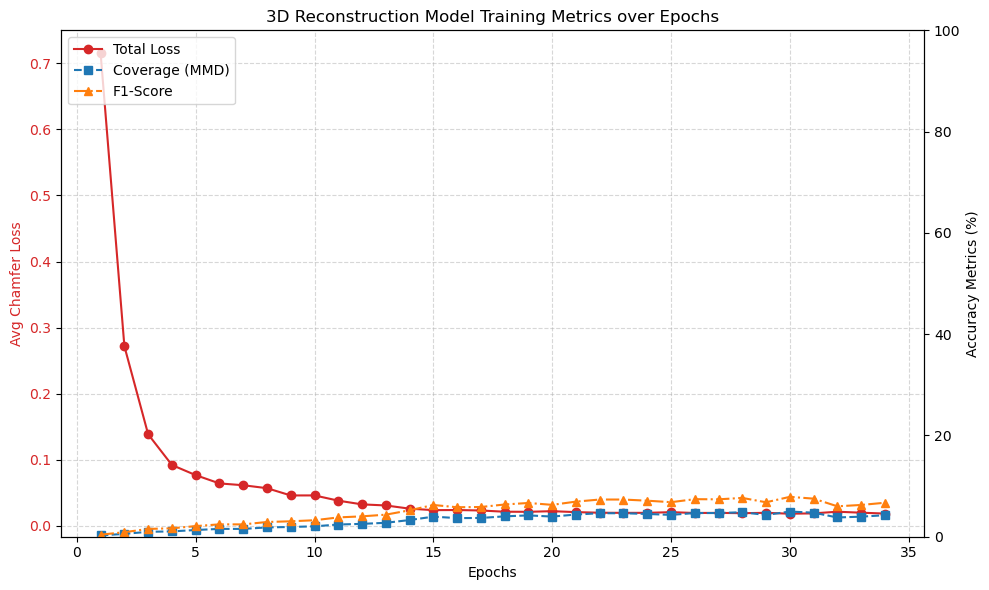

In [4]:
# 1. 데이터 파이프라인 가동 및 학습 테스트 시작
# (원활한 테스트 확인을 위해 세팅값을 작게 두었습니다. 필요시 조정 가능)
import torch.optim as optim
from torchinfo import summary
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# 모델 및 옵티마이저 선언
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Light3DReconstructModel(num_output_points=512).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)
# scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=1, eta_min=1e-6)
summary(model, input=(8, 1024, 3))
trained_model, history = train_reconstruct_model(
    model, optimizer, scheduler, device, epochs=100, steps_per_epoch=5, batch_size=8
)
plot_training_history(history)


[Test] 1개의 가상 테스트 데이터 생성 중...
[Test] 모델 피드포워드 및 3D 좌표 예측 중...

[Test 결과]
-> 전체 배치 학습용 Loss: 0.0260
--------------------------------------------------
-> [정밀도] CD-Precision (예측->정답 평균오차 거리): 0.0595
-> [커버율] CD-Recall    (정답->예측 평균오차 거리): 0.0614
--------------------------------------------------
-> 3D 표면 공간 커버리지 (Coverage @ 0.05): 25.10%
-> 3D F-Score 최종 정확도 (F-Score  @ 0.05): 27.76%


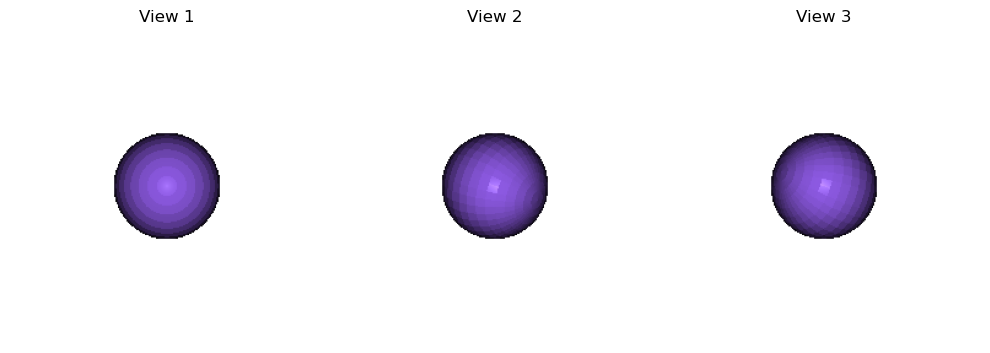


3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]


In [5]:
def test_reconstruct_model(model, threshold=0.05):
    """테스트 데이터 1개에 대해 CD Loss와 F-Score 정확도를 계산하고 결과를 시각화합니다."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()  # 평가 모드로 전환 (BatchNorm 등을 고정)

    print("\n[Test] 1개의 가상 테스트 데이터 생성 중...")
    image_datas, gt_datas = create_data(data_num=1)

    # 차원 정렬 및 텐서 변환 (Batch 크기 = 1)
    imgs = image_datas[0]
    img1 = (torch.from_numpy(imgs[0]).permute(2, 0, 1).float().unsqueeze(0).to(device))
    img2 = (torch.from_numpy(imgs[1]).permute(2, 0, 1).float().unsqueeze(0).to(device))
    img3 = (torch.from_numpy(imgs[2]).permute(2, 0, 1).float().unsqueeze(0).to(device))

    # 손실 함수 계산을 위해 GT도 텐서로 변환 (1, M, 3)
    gt_points_np = gt_datas[0]
    gt_points_tensor = (
        torch.from_numpy(gt_points_np).float().unsqueeze(0).to(device)
    )

    # gt_points = gt_datas[0]  # numpy array (4096, 3)

    print("[Test] 모델 피드포워드 및 3D 좌표 예측 중...")
    with torch.no_grad():
        pred_points_tensor_arr = model(img1, img2, img3)  # (1, 1024, 3)
        pred_points_tensor = pred_points_tensor_arr[0]
        # 1. 테스트 데이터에 대한 CD Loss 계산
        # test_loss = chamfer_distance_loss(pred_points_tensor, gt_points_tensor)
        # 총 손실함수
        test_loss = total_loss_fn(pred_points_tensor_arr, gt_points_tensor)

        # 2. 3D 정확도 (F-Score) 계산을 위한 거리 매트릭스 계산
        # (1, 1024, 1, 3) - (1, 1, 4096, 3) -> (1024, 4096)
        diff = pred_points_tensor.squeeze(0).unsqueeze(1) - gt_points_tensor.squeeze(0).unsqueeze(0)
        dist_matrix = torch.norm(diff, dim=-1)  # 제곱이 아닌 실제 유클리드 거리 (L2)

        # 예측된 점 각각이 GT와 가장 가까운 거리
        src_to_tgt_dist, _ = torch.min(dist_matrix, dim=1)
        # GT 점 각각이 예측된 점과 가장 가까운 거리
        tgt_to_src_dist, _ = torch.min(dist_matrix, dim=0)

        # 분리형 오차 거리 계산
        cd_precision = torch.mean(src_to_tgt_dist).item()
        cd_recall = torch.mean(tgt_to_src_dist).item()
        # 3. [통일] MMD 기반 공간 표면 커버리지 계산
        coverage = torch.mean((tgt_to_src_dist < threshold).float()).item() * 100

        # 4. [통일] 교정된 3D F-Score 정확도 계산
        precision = torch.mean((src_to_tgt_dist < threshold).float()).item()
        recall = torch.mean((tgt_to_src_dist < threshold).float()).item()

        # 조화평균을 구하여 최종 F-Score(정확도) 산출
        if precision + recall > 0:
            f_score = 2 * (precision * recall) / (precision + recall) * 100
        else:
            f_score = 0.0

    # numpy 변환 (시각화용)
    pred_points_np = pred_points_tensor.squeeze(0).cpu().numpy()

    print("\n" + "=" * 40)
    print(f"[Test 결과]")
    print(f"-> 전체 배치 학습용 Loss: {test_loss.item():.4f}")
    print("-" * 50)
    print(f"-> [정밀도] CD-Precision (예측->정답 평균오차 거리): {cd_precision:.4f}")
    print(f"-> [커버율] CD-Recall    (정답->예측 평균오차 거리): {cd_recall:.4f}")
    print("-" * 50)
    print(f"-> 3D 표면 공간 커버리지 (Coverage @ {threshold}): {coverage:.2f}%")
    print(f"-> 3D F-Score 최종 정확도 (F-Score  @ {threshold}): {f_score:.2f}%")


    print("=" * 40)

    fig, axes = plt.subplots(1, len(imgs), figsize=(10, 4))
    for i, img in enumerate(imgs):
        axes[i].imshow(img)
        axes[i].set_title(f"View {i+1}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

    # === 시각화 구성 ===
    # 1. 정답(GT) 점군 생성 -> 초록색으로 표시
    pcd_gt = o3d.geometry.PointCloud()
    pcd_gt.points = o3d.utility.Vector3dVector(gt_points_np)
    pcd_gt.paint_uniform_color([0, 0.8, 0])  # Green

    # 2. 예측(Pred) 점군 생성 -> 빨간색으로 표시
    pcd_pred = o3d.geometry.PointCloud()
    pcd_pred.points = o3d.utility.Vector3dVector(pred_points_np)
    pcd_pred.paint_uniform_color([1, 0, 0])  # Red



    # 3. 포아송 분포로 입체 도형 생성
    # 면을 생성하기 위해 점들의 법선(Normals)을 먼저 계산합니다.
    pcd_pred.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30)
    )
    pcd_pred.orient_normals_consistent_tangent_plane(k=15)

    # Poisson Reconstruction 실행 (depth가 높을수록 촘촘하고 디테일해집니다. 기본 8~9 추천)
    mesh_pred, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
        pcd_pred, depth=9
    )
    # 포아송 특성상 점군 바깥쪽 영역까지 과도하게 채워진 외곽 쓰레기 면들을 제거합니다.
    # 점들의 밀도가 임계값 이하인 유령 면들을 잘라내어 깔끔하게 마감합니다.
    densities = np.asarray(densities)
    density_mesh_to_remove = densities < np.quantile(densities, 0.05) # 하위 5% 밀도 영역 제거
    mesh_pred.remove_vertices_by_mask(density_mesh_to_remove)

    # 면의 안팎 방향을 바깥쪽(카메라 방향)으로 올바르게 뒤집기
    mesh_pred.orient_triangles() 

    # 입체 셰이딩 및 주홍색 단색 칠하기
    mesh_pred.compute_vertex_normals()
    mesh_pred.paint_uniform_color([0.9, 0.3, 0.3])




    # 3. 두 점군을 나란히 보거나 겹쳐서 확인하기 위해 x축으로 살짝 이동시킨 복사본 생성
    # 왼쪽에는 정답, 오른쪽에는 예측을 두고 겹친 것도 함께 봅니다.
    aabb = pcd_gt.get_axis_aligned_bounding_box()
    extent_x = (aabb.get_extent()[0] * 2.5)  # 도형 X축 크기의 2.5배만큼 떨어뜨려 겹침 방지

    pcd_pred_shifted = o3d.geometry.PointCloud(pcd_pred)
    pcd_pred_shifted.translate([extent_x, 0, 0])  # 오른쪽으로 이동

    pcd_gt_shifted = o3d.geometry.PointCloud(pcd_gt)
    pcd_gt_shifted.translate([-extent_x, 0, 0])  # 왼쪽으로 이동

    mesh_pred_shifted = o3d.geometry.TriangleMesh(mesh_pred)
    mesh_pred_shifted.translate([extent_x * 2, 0, 0])  # 맨 오른쪽 (입체 도형)

    pcd_pred.normals = o3d.utility.Vector3dVector([])          # 두번째 자리용
    pcd_pred_shifted.normals = o3d.utility.Vector3dVector([])  # 세번째 자리용
    print("\n3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측 | 맨우측(주홍): 예측 입체도형]]"    )
    o3d.visualization.draw_geometries(
        [pcd_gt_shifted, pcd_gt, pcd_pred, pcd_pred_shifted, mesh_pred_shifted], width=400, height=250
    )


# 2. 테스트 함수 가동
test_reconstruct_model(trained_model)

In [ ]:

# [Test] 1개의 가상 테스트 데이터 생성 중...
# [Test] 모델 피드포워드 및 3D 좌표 예측 중...

# ========================================
# [Test 결과]
# -> 전체 배치 학습용 Loss: 0.0079
# --------------------------------------------------
# -> [정밀도] CD-Precision (예측->정답 평균오차 거리): 0.0581
# -> [커버율] CD-Recall    (정답->예측 평균오차 거리): 0.0558
# --------------------------------------------------
# -> 3D 표면 공간 커버리지 (Coverage @ 0.05): 40.38%
# -> 3D F-Score 최종 정확도 (F-Score  @ 0.05): 42.53%
# ========================================

# 3D 시각화 창을 띄웁니다. [왼쪽(초록): 정답 | 가운데: 정답+예측 겹침 | 오른쪽(빨강): 모델예측]

In [ ]:
# - [3단계: SimpleNet 방식의 이상 탐지 학습]
# <br> - 진짜 정답(GT Point Cloud) 추출
# <br> - [정상 데이터]로 취급하여 학습
# <br> - 여기에 가우시안 노이즈를 섞어 분포를 비튼 [가짜 불량 데이터] 생성
# <br> - 판별기(Discriminator)가 진짜 정답과 가짜 노이즈 데이터를 구분하도록 학습
